In [41]:
import glob

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs

In [2]:
infiles = sorted(glob.glob('/g/data/xv83/dbi599/rba/Rx1day/ACCESS-CM2/ssp370/rx1day_yr_ACCESS-CM2_ssp370_r*i1p1f1_gn_1850-2100.nc'))

In [3]:
infiles

['/g/data/xv83/dbi599/rba/Rx1day/ACCESS-CM2/ssp370/rx1day_yr_ACCESS-CM2_ssp370_r10i1p1f1_gn_1850-2100.nc',
 '/g/data/xv83/dbi599/rba/Rx1day/ACCESS-CM2/ssp370/rx1day_yr_ACCESS-CM2_ssp370_r1i1p1f1_gn_1850-2100.nc',
 '/g/data/xv83/dbi599/rba/Rx1day/ACCESS-CM2/ssp370/rx1day_yr_ACCESS-CM2_ssp370_r2i1p1f1_gn_1850-2100.nc',
 '/g/data/xv83/dbi599/rba/Rx1day/ACCESS-CM2/ssp370/rx1day_yr_ACCESS-CM2_ssp370_r3i1p1f1_gn_1850-2100.nc',
 '/g/data/xv83/dbi599/rba/Rx1day/ACCESS-CM2/ssp370/rx1day_yr_ACCESS-CM2_ssp370_r4i1p1f1_gn_1850-2100.nc',
 '/g/data/xv83/dbi599/rba/Rx1day/ACCESS-CM2/ssp370/rx1day_yr_ACCESS-CM2_ssp370_r5i1p1f1_gn_1850-2100.nc',
 '/g/data/xv83/dbi599/rba/Rx1day/ACCESS-CM2/ssp370/rx1day_yr_ACCESS-CM2_ssp370_r6i1p1f1_gn_1850-2100.nc',
 '/g/data/xv83/dbi599/rba/Rx1day/ACCESS-CM2/ssp370/rx1day_yr_ACCESS-CM2_ssp370_r7i1p1f1_gn_1850-2100.nc',
 '/g/data/xv83/dbi599/rba/Rx1day/ACCESS-CM2/ssp370/rx1day_yr_ACCESS-CM2_ssp370_r8i1p1f1_gn_1850-2100.nc',
 '/g/data/xv83/dbi599/rba/Rx1day/ACCESS-CM2/s

In [4]:
ds = xr.open_mfdataset(infiles, combine='nested', concat_dim='run')

In [5]:
ds

<xarray.Dataset> Size: 278MB
Dimensions:  (run: 10, time: 251, lat: 144, lon: 192)
Coordinates:
  * lat      (lat) float64 1kB -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
  * time     (time) datetime64[ns] 2kB 1850-01-01 1851-01-01 ... 2100-01-01
Dimensions without coordinates: run
Data variables:
    Rx1day   (run, time, lat, lon) float32 278MB dask.array<chunksize=(1, 251, 144, 192), meta=np.ndarray>
Attributes: (12/48)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP AerChemMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_in_parent:  60265.0
    contact:                access_csiro@csiro.au
    ...                     ...
    variable_id:            pr
    variant_label:          r10i1p1f1
    version:                v20231017
    license:                CMIP6 model data produced by CSIRO is licensed un...
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/068b1f77-a736-4513-88ea-8a5660310118

In [6]:
ds_baseline = ds.sel(time=slice('1850-01-01', '1890-12-31'))
baseline_50pctl = ds_baseline['Rx1day'].quantile(0.5, dim=('time', 'run'))
baseline_50pctl = baseline_50pctl.compute()
baseline_95pctl = ds_baseline['Rx1day'].quantile(0.95, dim=('time', 'run'))
baseline_95pctl = baseline_95pctl.compute()

In [7]:
ds_future = ds.sel(time=slice('2060-01-01', '2100-12-31'))
future_50pctl = ds_future['Rx1day'].quantile(0.5, dim=('time', 'run'))
future_50pctl = future_50pctl.compute()
future_95pctl = ds_future['Rx1day'].quantile(0.95, dim=('time', 'run'))
future_95pctl = future_95pctl.compute()

In [8]:
change_50pctl = future_50pctl - baseline_50pctl
change_50pctl_pct = (change_50pctl / baseline_50pctl) * 100

In [9]:
change_95pctl = future_95pctl - baseline_95pctl
change_95pctl_pct = (change_95pctl / baseline_95pctl) * 100

In [46]:
diff = change_95pctl - change_50pctl
diff_pct = change_95pctl_pct - change_50pctl_pct

In [43]:
levels_mm = np.arange(-90, 91, 15)
levels_pct = np.arange(-90, 91, 15)

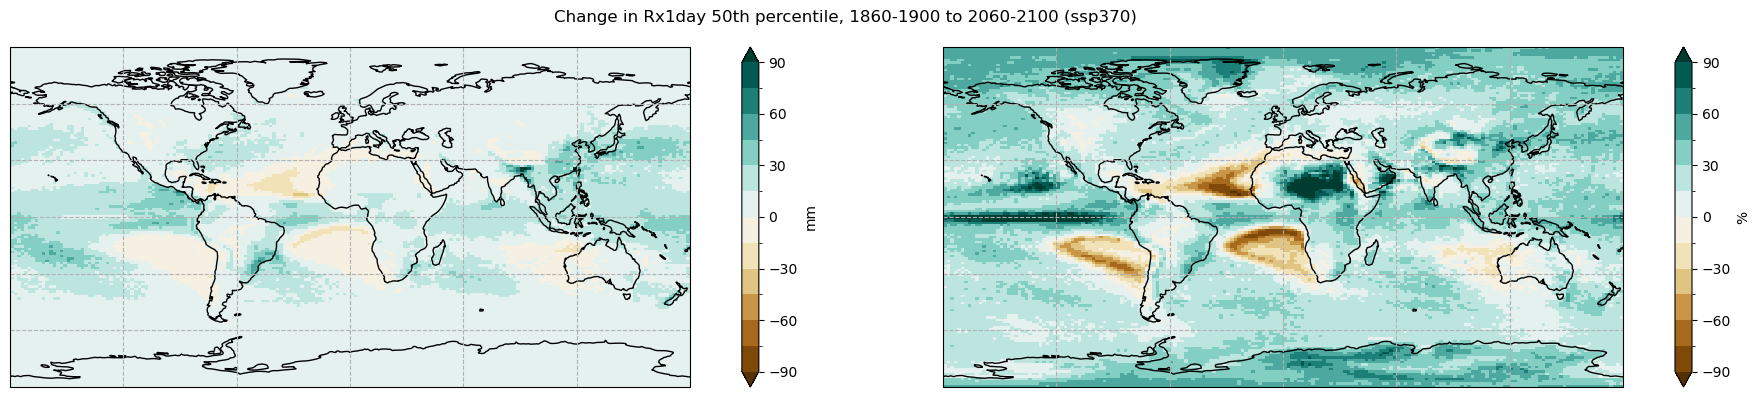

In [44]:
fig = plt.figure(figsize=[20, 4])

ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
change_50pctl.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap='BrBG',
    levels=levels_mm,
    extend='both',
    cbar_kwargs={"label": 'mm'},
)
ax1.coastlines()
ax1.gridlines(linestyle="--", draw_labels=False)
ax1.set_title('')

ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())
change_50pctl_pct.plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cmap='BrBG',
    levels=levels_pct,
    extend='both',
    cbar_kwargs={"label": '%'},
)
ax2.coastlines()
ax2.gridlines(linestyle="--", draw_labels=False)
ax2.set_title('')

plt.suptitle('Change in Rx1day 50th percentile, 1860-1900 to 2060-2100 (ssp370)')
plt.tight_layout()
plt.subplots_adjust(wspace=-0.1)
plt.show()

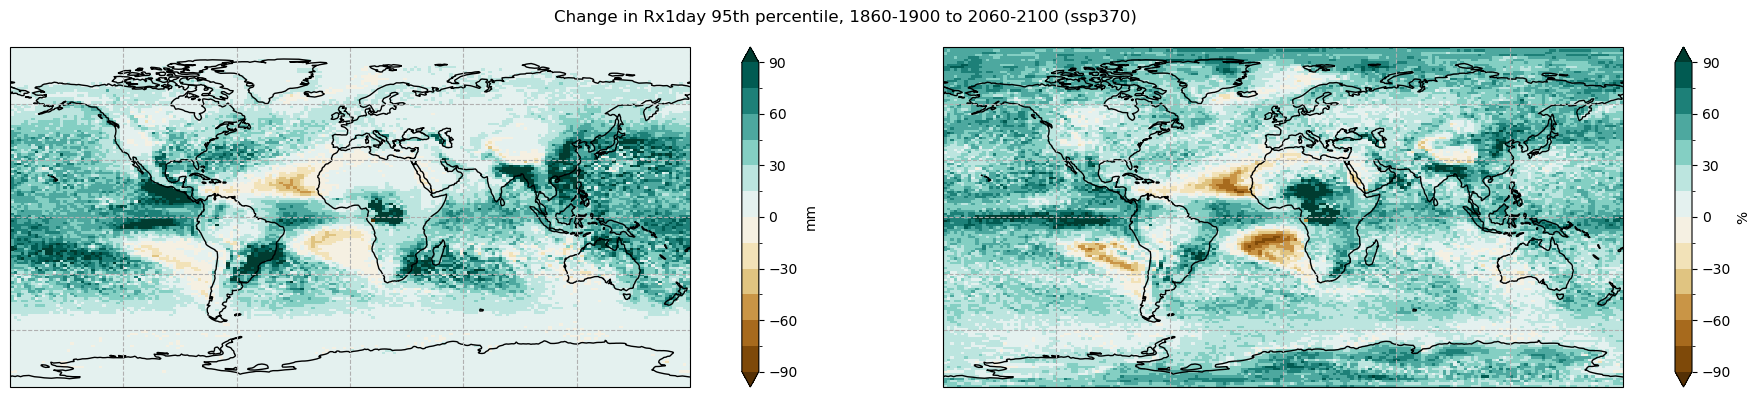

In [45]:
fig = plt.figure(figsize=[20, 4])

ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
change_95pctl.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap='BrBG',
    levels=levels_mm,
    extend='both',
    cbar_kwargs={"label": 'mm'},
)
ax1.coastlines()
ax1.gridlines(linestyle="--", draw_labels=False)
ax1.set_title('')

ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())
change_95pctl_pct.plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cmap='BrBG',
    levels=levels_pct,
    extend='both',
    cbar_kwargs={"label": '%'},
)
ax2.coastlines()
ax2.gridlines(linestyle="--", draw_labels=False)
ax2.set_title('')

plt.suptitle('Change in Rx1day 95th percentile, 1860-1900 to 2060-2100 (ssp370)')
plt.tight_layout()
plt.subplots_adjust(wspace=-0.1)
plt.show()

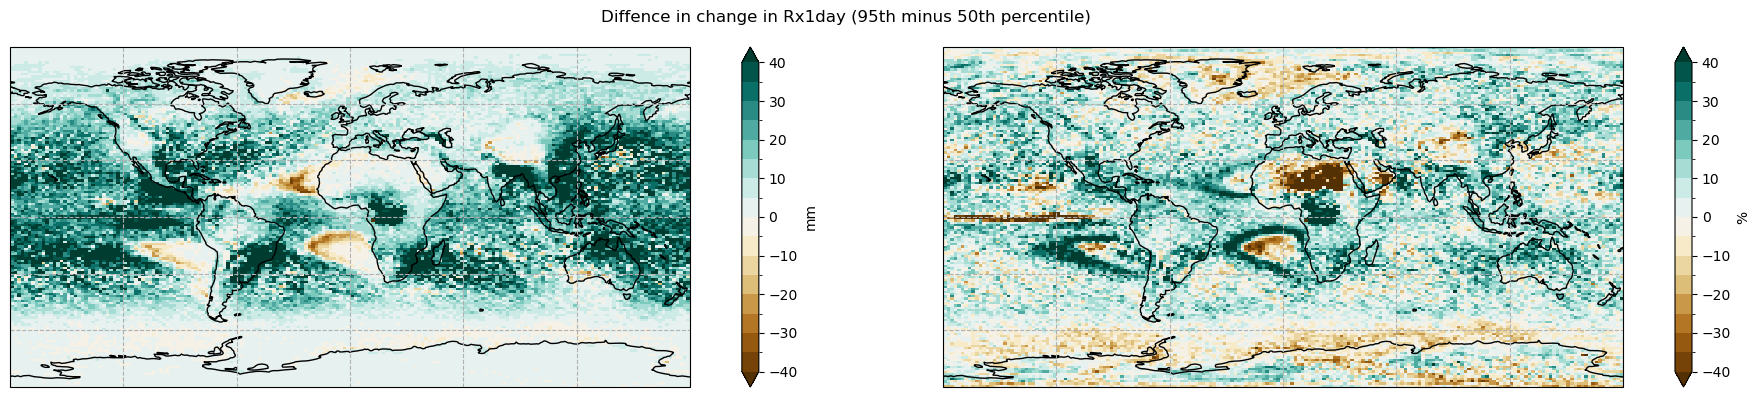

In [48]:
fig = plt.figure(figsize=[20, 4])

ax1 = fig.add_subplot(121, projection=ccrs.PlateCarree())
diff.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap='BrBG',
    levels=np.arange(-40, 41, 5),
    extend='both',
    cbar_kwargs={"label": 'mm'},
)
ax1.coastlines()
ax1.gridlines(linestyle="--", draw_labels=False)
ax1.set_title('')

ax2 = fig.add_subplot(122, projection=ccrs.PlateCarree())
diff_pct.plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cmap='BrBG',
    levels=np.arange(-40, 41, 5),
    extend='both',
    cbar_kwargs={"label": '%'},
)
ax2.coastlines()
ax2.gridlines(linestyle="--", draw_labels=False)
ax2.set_title('')

plt.suptitle('Diffence in change in Rx1day (95th minus 50th percentile)')
plt.tight_layout()
plt.subplots_adjust(wspace=-0.1)
plt.show()